# Nordschleife Analysis

## Introduction
The Nürburgring Nordschleife is regarded as the benchmark for vehicle performance.
With its unique combination of high-speed straights, technical corners, elevation changes, and demanding track conditions, it provides one of the most comprehensive tests for both drivers and cars.

This project focuses on the analysis of the Nürburgring Nordschleife lap times. The objective is to build a machine learning model that predicts Nordschleife lap times from vehicle specifications. The goal is to uncover patterns that influence track performance and have some fun with cars.

### Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz

## Getting the Data

The raw lap-time dataset was merged with a sports-car specification dataset.
The final dataset used in this analysis was generated using the data preparation pipeline implemented in `Data.py`.
The script performs:

- Data loading
- Vehicle name standardization
- Unit conversions
- Fuzzy matching
- Dataset merging
- Final dataset creation

The resulting dataset (`nls`) is used throughout this notebook and contains following columns:

- **Time**: Lap Time
- **Vehicle**: Vehicle Name
- **Driver**: Driver Name
- **Date**: Date
- **Year**: Production Year of the car
- **Engine Size (L)**: Engine Size in Liters
- **HP**: Horsepower
- **Torque (Nm)**:Torque in Nm
- **0-100**: 0 - 100 km/h time
- **Price (EUR)**: Price in Euro



## Insights from Statistics

In [6]:
nls = pd.read_csv("../Data/nls.csv")

In [4]:
## Quick look at the data
print(nls.describe())

             Time         Year  Engine Size (L)           HP  Torque (Nm)  \
count  208.000000   208.000000       202.000000   208.000000   208.000000   
mean     7.842388  2020.995192         3.985149   535.264423   667.692308   
std      0.549537     1.944887         1.362058   171.099943   224.521610   
min      6.800000  2014.000000         1.700000   237.000000   320.000000   
25%      7.483333  2021.000000         3.000000   405.000000   500.000000   
50%      7.825000  2021.000000         4.000000   562.000000   659.500000   
75%      8.175000  2022.000000         4.400000   625.000000   800.000000   
max     11.416667  2023.000000         8.400000  1914.000000  2299.000000   

            0-100   Price (EUR)  
count  208.000000  2.080000e+02  
mean     3.520240  1.339080e+05  
std      0.667637  2.055364e+05  
min      1.850000  2.557650e+04  
25%      3.100000  5.780000e+04  
50%      3.500000  8.602000e+04  
75%      3.900000  1.578238e+05  
max      5.200000  2.040000e+06  



**Lap Time Distribution**
- Fastest lap time: **6.80 min**
- Slowest lap time: **11.42 min**
- Lap time standard deviation is relatively low, indicating that most vehicles achieve similar lap times.
- The slowest lap time is likely an outlier, as the second-slowest time is only **8.90 min**.
- The **75th percentile (8.18 min)** is much closer to the median than to the maximum value, further suggesting an outlier.

**Vehicle Age**
- Most vehicles were produced between **2014 and 2023**
- The dataset therefore represents a relatively modern collection of performance cars.

**Performance Characteristics**
- Average vehicle performance is very high:
  - **535 hp** average horsepower
  - **667 Nm** average torque
- Engine displacement ranges up to **8.4 liters**, with an average of roughly **4.0 liters**.
- The dataset mainly consists of premium and high-performance vehicles with powerful engines.

**Vehicle Prices**
- Vehicle prices range from approximately **€133,900** to **€2,040,000**.
- The dataset contains mostly premium and high-performance vehicles rather than economy cars.
- Price values show considerable variation across vehicles.

**Potential Outliers**

- The maximum horsepower (**1,914 hp**) and torque (**2,299 Nm**) are substantially higher than the 75th percentile values (**625 hp**, **800 Nm**), indicating a few extreme-performance outliers.
- Similar outlier patterns can be observed for lap time, price, and engine displacement.

**Missing Values**
- Most variables contain no missing values.
- Missing data is primarily limited to the **engine displacement** feature, with only 6 missing values





## Exploratory data analysis


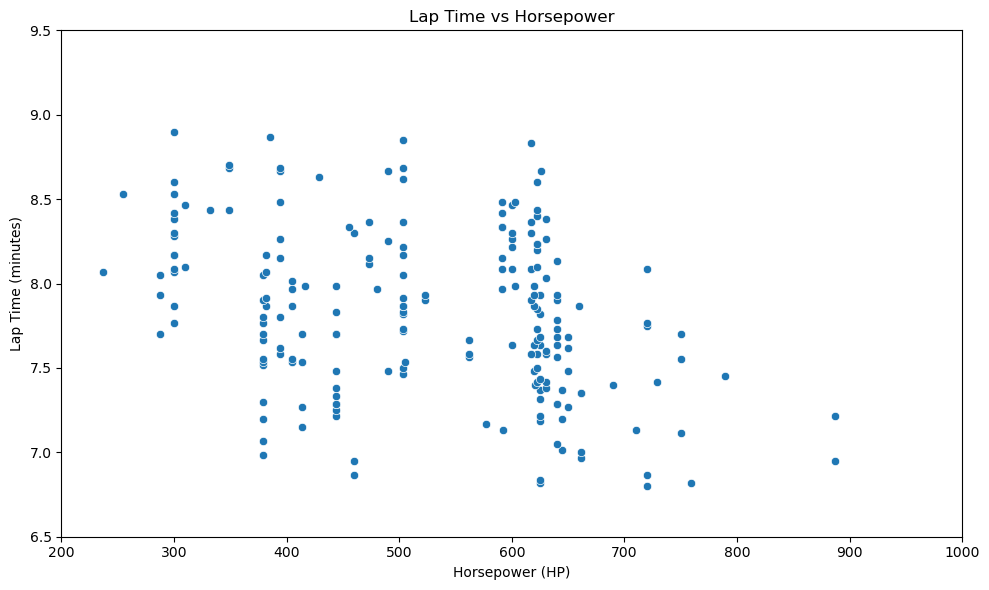

In [23]:
## plotting lap times against horsepower
plt.figure(figsize = (10, 6))
sns.scatterplot(data = nls, x = 'HP', y = 'Time')
plt.xlim(200, 1000)
plt.ylim(6.5, 9.5)
plt.title('Lap Time vs Horsepower')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Lap Time (minutes)')
plt.tight_layout()
plt.show()



### Key Findings from the Scatterplot

**Relationship Between Horsepower and Lap Time**
- No strong linear relationship between horsepower and Nürburgring lap time is visible.
- The scatter plot shows a large spread of lap times across nearly all horsepower ranges.
- A slight downward trend can be observed, suggesting that higher horsepower may contribute to faster lap times.

**Comparison of Low- and High-Power Vehicles**
- Vehicles with lower horsepower (approximately 250–400 HP) tend to record slightly slower lap times.
- Vehicles with higher horsepower (approximately 600–800 HP) generally achieve somewhat faster lap times.
- However, the difference is not large enough to indicate a strong dependency.

**Variability Within Horsepower Classes**
- Cars with more than 600 HP exhibit both very fast and relatively slow lap times.
- The variation within the same horsepower range is substantial.
- This suggests that horsepower alone does not determine track performance.

**Notable Observations**
- Some vehicles with around 450 HP achieve faster lap times than vehicles with nearly 900 HP.
- Several cars with similar horsepower values differ by more than one minute in lap time.
- High horsepower does not automatically translate into a faster Nürburgring lap.


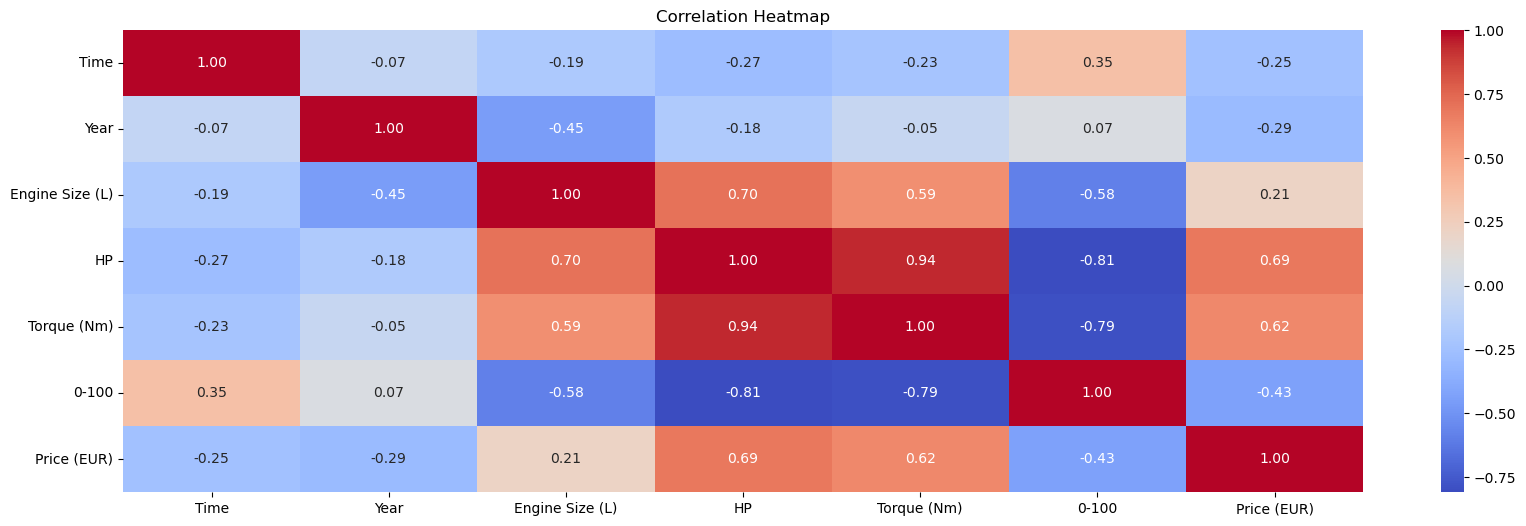

In [43]:
## Correlation Heatmap
corr = nls.select_dtypes(include = 'number').corr()

plt.figure(figsize = (20, 6))
sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('Correlation Heatmap')
plt.show()



### Key Findings from the Correlation Analysis
**HP and Torque show a very strong positive correlation (r = 0.94).**
- Cars with higher horsepower generally also produce more torque.
- This is expected since both variables measure engine performance.

**0–100 km/h acceleration is strongly negatively correlated with HP (r = -0.81) and Torque (r = -0.79).**
- More powerful cars tend to accelerate faster.
- Since lower 0–100 times are better, the negative correlation is expected.

**Lap Time is only weakly to moderately correlated with the available vehicle characteristics.**
- HP: r = -0.27
- Torque: r = -0.23
- Engine Size: r = -0.19
- Price: r = -0.25
- This suggests that Nürburgring lap times are influenced by additional factors such as aerodynamics, tire grip, weight, suspension setup and drivetrain

**Lap Time has the strongest relationship with 0–100 km/h acceleration (r = 0.35).**
- Cars with slower acceleration tend to have slower lap times.
- However, the relationship is still only moderate.

**Vehicle Year and Engine Size are moderately negatively correlated (r = -0.45).**
- Newer vehicles tend to have smaller engines.
- This likely reflects modern engine downsizing and turbocharging technologies, which allow manufacturers to achieve high performance with lower displacement.

**Price is positively correlated with HP (r = 0.69) and Torque (r = 0.62).**
- More expensive vehicles generally offer higher performance.
- However, price alone is not a strong predictor of lap time (r = -0.25).



In [38]:
## Plotting Price and Lap Time


In [39]:
## Plotting Year and Lap Time


In [40]:
## Plotting the top 10 cars with the fastest lap times


## Model

### Train the model

### Choose best model